# Multi Source Pipeline

In [1]:
# import libraries

import requests
import pandas as pd
import numpy as np

In [2]:
# url of coingecko api 

url = "https://api.coingecko.com/api/v3/coins/markets"

In [3]:
# api parameters

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": "false",
    "price_change_percentage": "1h,24h,7d,30d"
}

In [4]:
#  SEND REQUEST TO COINGECKO API

response = requests.get(url, params=params)

print(response.status_code)

200


In [5]:
# convert api response to json

data = response.json()

print("Data Type:", type(data))

# API sends the data back as JSON so we need to send response in json only 

Data Type: <class 'list'>


In [6]:
# check number of records

print("Number of Records:", len(data))

Number of Records: 100


In [7]:
# inspect first cryptocurrency record

data[0]

{'id': 'bitcoin',
 'symbol': 'btc',
 'name': 'Bitcoin',
 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400',
 'current_price': 79596,
 'market_cap': 1598066676543,
 'market_cap_rank': 1,
 'fully_diluted_valuation': 1598066676543,
 'total_volume': 34589793115,
 'high_24h': 79701,
 'low_24h': 77666,
 'price_change_24h': 1233.79,
 'price_change_percentage_24h': 1.57447,
 'market_cap_change_24h': 24446387300,
 'market_cap_change_percentage_24h': 1.55351,
 'circulating_supply': 20081840.0,
 'total_supply': 20081850.0,
 'max_supply': 21000000.0,
 'ath': 126080,
 'ath_change_percentage': -36.86856,
 'ath_date': '2025-10-06T10:57:42.000Z',
 'atl': 67.81,
 'atl_change_percentage': 117282.714,
 'atl_date': '2013-07-05T16:00:00.000Z',
 'roi': None,
 'last_updated': '2026-09-09T12:52:20.000Z',
 'price_change_percentage_1h_in_currency': 0.5,
 'price_change_percentage_24h_in_currency': 1.57447,
 'price_change_percentage_30d_in_currency': 22.1,
 'price_change_per

In [8]:
# convert json to data frame

crypto_raw = pd.DataFrame(data)

crypto_raw.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,79596.000000,1598066676543,1,1598066676543,3.458979e+10,79701.000000,...,2025-10-06T10:57:42.000Z,67.810000,1.172827e+05,2013-07-05T16:00:00.000Z,None,2026-09-09T12:52:20.000Z,0.5,1.57447,22.1,3.5
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2510.810000,306289554849,2,306289554849,1.235283e+10,2521.510000,...,2025-08-24T11:21:03.000Z,0.432979,5.797929e+05,2015-10-19T16:00:00.000Z,"{'times': 41.18016117359348, 'currency': 'btc'...",2026-09-09T12:52:20.000Z,0.6,1.53175,30.6,5.5
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999822,183424711629,3,188890600134,5.347736e+10,0.999995,...,2018-07-23T16:00:00.000Z,0.572521,7.463505e+01,2015-03-01T16:00:00.000Z,None,2026-09-09T12:52:20.000Z,0.0,0.02292,0.1,0.0
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,750.380000,99898084263,4,99898094646,9.268853e+08,757.360000,...,2025-10-13T00:41:24.000Z,0.039818,1.884451e+06,2017-10-18T16:00:00.000Z,None,2026-09-09T12:52:20.000Z,0.0,-0.10175,23.9,10.0
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.440000,90117640590,5,143605705099,2.691625e+09,1.450000,...,2025-07-17T19:40:53.000Z,0.002686,5.341080e+04,2014-05-21T16:00:00.000Z,None,2026-09-09T12:52:20.000Z,0.4,2.81569,38.4,8.2


In [9]:
# check data shape 

crypto_raw.shape

(100, 30)

In [10]:
# check column names

crypto_raw.columns.tolist()

['id',
 'symbol',
 'name',
 'image',
 'current_price',
 'market_cap',
 'market_cap_rank',
 'fully_diluted_valuation',
 'total_volume',
 'high_24h',
 'low_24h',
 'price_change_24h',
 'price_change_percentage_24h',
 'market_cap_change_24h',
 'market_cap_change_percentage_24h',
 'circulating_supply',
 'total_supply',
 'max_supply',
 'ath',
 'ath_change_percentage',
 'ath_date',
 'atl',
 'atl_change_percentage',
 'atl_date',
 'roi',
 'last_updated',
 'price_change_percentage_1h_in_currency',
 'price_change_percentage_24h_in_currency',
 'price_change_percentage_30d_in_currency',
 'price_change_percentage_7d_in_currency']

In [11]:
# initial data set information

crypto_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       100 non-null    object 
 1   symbol                                   100 non-null    object 
 2   name                                     100 non-null    object 
 3   image                                    100 non-null    object 
 4   current_price                            100 non-null    float64
 5   market_cap                               100 non-null    int64  
 6   market_cap_rank                          100 non-null    int64  
 7   fully_diluted_valuation                  100 non-null    int64  
 8   total_volume                             100 non-null    float64
 9   high_24h                                 100 non-null    float64
 10  low_24h                                  100 non-nu

In [12]:
# check missing values

crypto_raw.isnull().sum()

id                                          0
symbol                                      0
name                                        0
image                                       0
current_price                               0
market_cap                                  0
market_cap_rank                             0
fully_diluted_valuation                     0
total_volume                                0
high_24h                                    0
low_24h                                     0
price_change_24h                            2
price_change_percentage_24h                 2
market_cap_change_24h                       2
market_cap_change_percentage_24h            2
circulating_supply                          0
total_supply                                0
max_supply                                 47
ath                                         0
ath_change_percentage                       0
ath_date                                    0
atl                               

In [13]:
# check duplicate cyptocurrencies

print("Duplicate IDs:", crypto_raw["id"].duplicated().sum())

Duplicate IDs: 0


In [14]:
# Check duplicate symbols

print("Duplicate Symbols:", crypto_raw["symbol"].duplicated().sum())

Duplicate Symbols: 0


In [15]:
# check their data types

crypto_raw.dtypes

id                                          object
symbol                                      object
name                                        object
image                                       object
current_price                              float64
market_cap                                   int64
market_cap_rank                              int64
fully_diluted_valuation                      int64
total_volume                               float64
high_24h                                   float64
low_24h                                    float64
price_change_24h                           float64
price_change_percentage_24h                float64
market_cap_change_24h                      float64
market_cap_change_percentage_24h           float64
circulating_supply                         float64
total_supply                               float64
max_supply                                 float64
ath                                        float64
ath_change_percentage          

In [16]:
# check for nested dictionary values

for column in crypto_raw.columns:
    if crypto_raw[column].apply(lambda x: isinstance(x, dict)).any():
        print(column)

roi


In [17]:
# check missing values

missing_values = crypto_raw.isnull().sum()

missing_values[missing_values > 0]

price_change_24h                            2
price_change_percentage_24h                 2
market_cap_change_24h                       2
market_cap_change_percentage_24h            2
max_supply                                 47
roi                                        91
price_change_percentage_1h_in_currency      1
price_change_percentage_24h_in_currency     2
price_change_percentage_30d_in_currency     1
price_change_percentage_7d_in_currency      1
dtype: int64

In [18]:
# check numerical summary 

crypto_raw.describe()

,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,market_cap_change_24h,...,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency
count,100.000000,1.000000e+02,100.000000,1.000000e+02,1.000000e+02,100.000000,100.000000,98.000000,98.000000,9.800000e+01,...,1.000000e+02,5.300000e+01,100.000000,100.000000,1.000000e+02,1.000000e+02,99.000000,98.000000,99.000000,99.000000
mean,949.289399,2.751908e+10,50.500000,2.965701e+10,1.446359e+09,951.090284,926.148422,14.241783,1.138810,3.689505e+08,...,1.911892e+13,2.686225e+13,1579.273826,-53.969196,3.147101e+01,1.614829e+05,0.376768,1.138810,26.292929,9.904040
std,7972.818422,1.631962e+11,29.011492,1.635282e+11,6.591902e+09,7983.424652,7779.961775,124.975361,5.305620,2.519552e+09,...,1.143606e+14,1.479812e+14,12618.947528,36.870182,2.002297e+02,1.031838e+06,0.848628,5.305620,33.411764,14.605485
min,0.000002,5.869188e+08,1.000000,5.943523e+08,0.000000e+00,0.000000,0.000000,-10.711259,-7.163640,-2.702899e+08,...,4.325033e+05,1.461249e+07,0.000004,-99.643890,5.636600e-11,0.000000e+00,-3.600000,-7.163640,-16.400000,-7.600000
25%,0.368859,1.015486e+09,25.750000,1.310851e+09,1.168644e+07,0.318394,0.312171,-0.000144,-0.044640,-7.870844e+06,...,5.325825e+08,4.000000e+08,1.033000,-87.412710,4.996459e-02,3.835247e+01,0.000000,-0.044640,0.400000,0.000000
50%,1.000000,1.933100e+09,50.500000,2.721091e+09,8.466000e+07,1.000000,0.999874,0.000347,0.041380,6.490460e+06,...,1.601888e+09,2.100000e+09,2.925000,-63.893760,5.230630e-01,2.712389e+02,0.200000,0.041380,19.700000,6.100000
75%,7.975000,4.221936e+09,75.250000,5.971756e+09,2.526303e+08,7.312500,7.172500,0.017846,1.584138,4.265154e+07,...,1.000000e+10,2.346267e+10,53.270000,-15.175455,9.975130e-01,2.656364e+03,0.600000,1.584138,37.650000,12.600000
max,79596.000000,1.598067e+12,100.000000,1.598067e+12,5.347736e+10,79701.000000,77666.000000,1233.790000,43.643300,2.444639e+10,...,8.982327e+14,9.999900e+14,126080.000000,0.000000,1.447840e+03,9.685125e+06,3.300000,43.643300,154.700000,69.100000


In [19]:
# unique values

print("Unique IDs:", crypto_raw["id"].nunique())
print("Unique Symbols:", crypto_raw["symbol"].nunique())
print("Unique Names:", crypto_raw["name"].nunique())

Unique IDs: 100
Unique Symbols: 100
Unique Names: 100


In [20]:
# save raw data

crypto_raw.to_csv("../data/raw/crypto_raw.csv",index=False)

print("Raw crypto dataset saved successfully!")

Raw crypto dataset saved successfully!


# Crypto Data Cleaning

In [21]:
# create a cleaning copy


crypto_clean = crypto_raw.copy()

print("Cleaning copy created successfully!")
print("Shape:", crypto_clean.shape)

Cleaning copy created successfully!
Shape: (100, 30)


In [22]:

# remove nested roi column

crypto_clean = crypto_clean.drop(columns=["roi"])

print("ROI column removed.")
print("New shape:", crypto_clean.shape)

ROI column removed.
New shape: (100, 29)


In [23]:
# check invalid crypto prices

negative_prices = (crypto_clean["current_price"] < 0).sum()
zero_prices = (crypto_clean["current_price"] == 0).sum()

print("Negative prices:", negative_prices)
print("Zero prices:", zero_prices)

Negative prices: 0
Zero prices: 0


In [24]:
# remove invalid prices

crypto_clean = crypto_clean[crypto_clean["current_price"] > 0].copy()

print("Shape after price validation:", crypto_clean.shape)

Shape after price validation: (100, 29)


In [25]:
# convert numeric colums

numeric_columns = [
    "current_price",
    "market_cap",
    "market_cap_rank",
    "fully_diluted_valuation",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_24h",
    "price_change_percentage_24h",
    "market_cap_change_24h",
    "market_cap_change_percentage_24h",
    "circulating_supply",
    "total_supply",
    "max_supply",
    "ath",
    "ath_change_percentage",
    "atl",
    "atl_change_percentage",
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_30d_in_currency",
    "price_change_percentage_7d_in_currency"
]

for column in numeric_columns:
    crypto_clean[column] = pd.to_numeric(
        crypto_clean[column],
        errors="coerce"      # it convert to NaN if data has not applicable,N/A, unknown
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [26]:
# convert data columns

date_columns = [
    "ath_date",
    "atl_date",
    "last_updated"
]

for column in date_columns:
    crypto_clean[column] = pd.to_datetime(
        crypto_clean[column],
        errors="coerce",
        utc=True
    )

print("Date conversion completed.")

Date conversion completed.


In [27]:
crypto_clean[date_columns].dtypes

ath_date        datetime64[ns, UTC]
atl_date        datetime64[ns, UTC]
last_updated    datetime64[ns, UTC]
dtype: object

In [28]:
# handle missing market change values

change_columns = [
    "price_change_24h",
    "price_change_percentage_24h",
    "market_cap_change_24h",
    "market_cap_change_percentage_24h",
    "price_change_percentage_24h_in_currency"
]

for column in change_columns:
    crypto_clean[column] = crypto_clean[column].fillna(
        crypto_clean[column].median()
    )

print("Missing market-change values handled.")

Missing market-change values handled.


In [29]:

# CHECK MISSING VALUES AFTER CLEANING


missing_after = crypto_clean.isnull().sum()

missing_after[missing_after > 0]

max_supply                                 47
price_change_percentage_1h_in_currency      1
price_change_percentage_30d_in_currency     1
price_change_percentage_7d_in_currency      1
dtype: int64

In [30]:

# FINAL DUPLICATE CHECK


print(
    "Duplicate IDs:",
    crypto_clean["id"].duplicated().sum()
)

print(
    "Duplicate Symbols:",
    crypto_clean["symbol"].duplicated().sum()
)

Duplicate IDs: 0
Duplicate Symbols: 0


In [31]:

#  CLEANED DATASET VALIDATION


print("Shape:", crypto_clean.shape)
print("\nData Types:")
print(crypto_clean.dtypes)

print("\nMissing Values:")
print(crypto_clean.isnull().sum()[crypto_clean.isnull().sum() > 0])

Shape: (100, 29)

Data Types:
id                                                      object
symbol                                                  object
name                                                    object
image                                                   object
current_price                                          float64
market_cap                                               int64
market_cap_rank                                          int64
fully_diluted_valuation                                  int64
total_volume                                           float64
high_24h                                               float64
low_24h                                                float64
price_change_24h                                       float64
price_change_percentage_24h                            float64
market_cap_change_24h                                  float64
market_cap_change_percentage_24h                       float64
circulating_supply       

# Crypto Outlier Analysis

In [32]:
# SELECT FEATURES FOR OUTLIER ANALYSIS

outlier_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]

print("Columns selected for outlier analysis:")
print(outlier_columns)

Columns selected for outlier analysis:
['current_price', 'market_cap', 'total_volume', 'price_change_percentage_24h']


In [33]:
# IQR OUTLIER DETECTION FUNCTION


def detect_iqr_outliers(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound

In [34]:
# APPLY IQR OUTLIER DETECTION

iqr_results = {}

for column in outlier_columns:
    
    outliers, lower_bound, upper_bound = detect_iqr_outliers(
        crypto_clean,
        column
    )
    
    iqr_results[column] = {
        "outlier_count": len(outliers),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

    print(f"\n{column}")
    print("Outliers:", len(outliers))
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


current_price
Outliers: 19
Lower Bound: -11.040353125
Upper Bound: 19.384211875

market_cap
Outliers: 17
Lower Bound: -3794187752.5
Upper Bound: 9031609763.5

total_volume
Outliers: 14
Lower Bound: -349729379.375
Upper Bound: 614046129.625

price_change_percentage_24h
Outliers: 20
Lower Bound: -2.47748875
Upper Bound: 4.01080125


In [35]:
# IQR OUTLIER SUMMARY


iqr_summary = pd.DataFrame(iqr_results).T

iqr_summary

,outlier_count,lower_bound,upper_bound
current_price,19.0,-1.104035e+01,1.938421e+01
market_cap,17.0,-3.794188e+09,9.031610e+09
total_volume,14.0,-3.497294e+08,6.140461e+08
price_change_percentage_24h,20.0,-2.477489e+00,4.010801e+00


In [36]:
# INSPECT MARKET CAP OUTLIERS


market_cap_outliers, lower_bound, upper_bound = detect_iqr_outliers(
    crypto_clean,
    "market_cap"
)

market_cap_outliers[
    ["id", "name", "current_price", "market_cap"]
].sort_values(
    "market_cap",
    ascending=False
)

,id,name,current_price,market_cap
0,bitcoin,Bitcoin,79596.000000,1598066676543
1,ethereum,Ethereum,2510.810000,306289554849
2,tether,Tether,0.999822,183424711629
3,binancecoin,BNB,750.380000,99898084263
4,ripple,XRP,1.440000,90117640590
5,usd-coin,USDC,0.999913,74316339805
6,solana,Solana,104.740000,61354019938
7,tron,TRON,0.338870,32172210716
8,figure-heloc,Figure Heloc,1.035000,23072571554
9,zcash,Zcash,1266.360000,21390127439


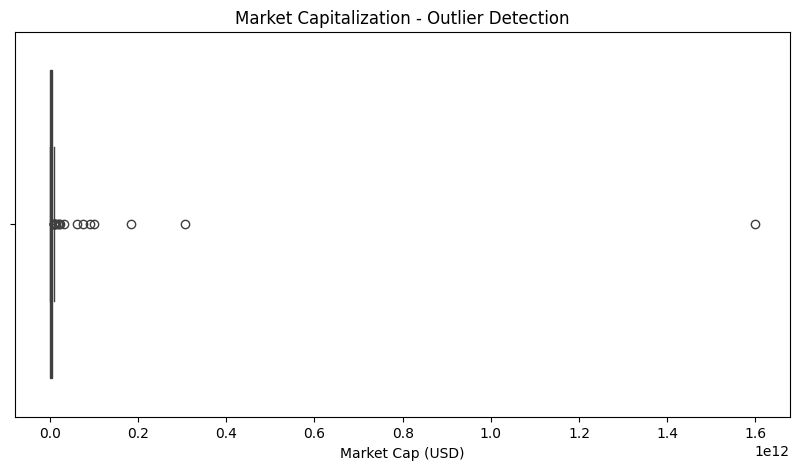

In [37]:
# BOX PLOT - MARKET CAP


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=crypto_clean["market_cap"]
)

plt.title("Market Capitalization - Outlier Detection")
plt.xlabel("Market Cap (USD)")

plt.show()

In [38]:
# IMPORT ISOLATION FOREST


from sklearn.ensemble import IsolationForest

In [39]:
#  PREPARE FEATURES FOR ISOLATION FOREST


isolation_features = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]

crypto_if = crypto_clean[isolation_features].copy()

crypto_if["current_price"] = np.log1p(
    crypto_if["current_price"]
)

crypto_if["market_cap"] = np.log1p(
    crypto_if["market_cap"]
)

crypto_if["total_volume"] = np.log1p(
    crypto_if["total_volume"]
)

crypto_if = crypto_if.replace(
    [np.inf, -np.inf],
    np.nan
)

crypto_if = crypto_if.fillna(
    crypto_if.median()
)

crypto_if.head()

,current_price,market_cap,total_volume,price_change_percentage_24h
0,11.284732,28.099816,24.266824,1.57447
1,7.828759,26.447797,23.237151,1.53175
2,0.693058,25.935070,24.702524,0.02292
3,6.621912,25.327416,20.647340,-0.10175
4,0.891998,25.224382,21.713411,2.81569


In [40]:

# APPLY ISOLATION FOREST


iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

crypto_if["outlier_prediction"] = iso_forest.fit_predict(
    crypto_if[isolation_features]
)

In [41]:
# ADD ISOLATION FOREST RESULTS


crypto_clean["isolation_outlier"] = crypto_if[
    "outlier_prediction"
]

crypto_clean["isolation_outlier"].value_counts()

isolation_outlier
 1    95
-1     5
Name: count, dtype: int64

In [42]:
# INSPECT ISOLATION FOREST OUTLIERS


crypto_clean[
    crypto_clean["isolation_outlier"] == -1
][
    [
        "id",
        "name",
        "current_price",
        "market_cap",
        "total_volume",
        "price_change_percentage_24h"
    ]
]

,id,name,current_price,market_cap,total_volume,price_change_percentage_24h
0,bitcoin,Bitcoin,79596.00,1598066676543,3.458979e+10,1.57447
1,ethereum,Ethereum,2510.81,306289554849,1.235283e+10,1.53175
9,zcash,Zcash,1266.36,21390127439,1.287680e+09,8.92927
66,venice-token,Venice Token,27.36,1309926472,2.864371e+08,43.64330
78,blockchain-capital,Blockchain Capital,106.49,970348700,0.000000e+00,0.25419


In [43]:
# CREATE OUTLIER FLAG

crypto_clean["is_outlier"] = (
    crypto_clean["isolation_outlier"] == -1
)

crypto_clean["is_outlier"].value_counts()

is_outlier
False    95
True      5
Name: count, dtype: int64

In [44]:
#  REMOVE TEMPORARY OUTLIER COLUMN

crypto_clean = crypto_clean.drop(
    columns=["isolation_outlier"]
)

crypto_clean.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_date,atl,atl_change_percentage,atl_date,last_updated,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency,is_outlier
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,79596.000000,1598066676543,1,1598066676543,3.458979e+10,79701.000000,...,2025-10-06 10:57:42+00:00,67.810000,1.172827e+05,2013-07-05 16:00:00+00:00,2026-09-09 12:52:20+00:00,0.5,1.57447,22.1,3.5,True
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2510.810000,306289554849,2,306289554849,1.235283e+10,2521.510000,...,2025-08-24 11:21:03+00:00,0.432979,5.797929e+05,2015-10-19 16:00:00+00:00,2026-09-09 12:52:20+00:00,0.6,1.53175,30.6,5.5,True
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999822,183424711629,3,188890600134,5.347736e+10,0.999995,...,2018-07-23 16:00:00+00:00,0.572521,7.463505e+01,2015-03-01 16:00:00+00:00,2026-09-09 12:52:20+00:00,0.0,0.02292,0.1,0.0,False
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,750.380000,99898084263,4,99898094646,9.268853e+08,757.360000,...,2025-10-13 00:41:24+00:00,0.039818,1.884451e+06,2017-10-18 16:00:00+00:00,2026-09-09 12:52:20+00:00,0.0,-0.10175,23.9,10.0,False
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.440000,90117640590,5,143605705099,2.691625e+09,1.450000,...,2025-07-17 19:40:53+00:00,0.002686,5.341080e+04,2014-05-21 16:00:00+00:00,2026-09-09 12:52:20+00:00,0.4,2.81569,38.4,8.2,False


# CRYPTO FEATURE ENGINEERING

In [45]:
#  CREATE MARKET CAP CATEGORY

def classify_market_cap(market_cap):
    
    if market_cap >= 10_000_000_000:
        return "Large Cap"
    
    elif market_cap >= 1_000_000_000:
        return "Mid Cap"
    
    else:
        return "Small Cap"


crypto_clean["market_cap_category"] = (
    crypto_clean["market_cap"]
    .apply(classify_market_cap)
)

crypto_clean[
    ["name", "market_cap", "market_cap_category"]
].head(10)

,name,market_cap,market_cap_category
0,Bitcoin,1598066676543,Large Cap
1,Ethereum,306289554849,Large Cap
2,Tether,183424711629,Large Cap
3,BNB,99898084263,Large Cap
4,XRP,90117640590,Large Cap
5,USDC,74316339805,Large Cap
6,Solana,61354019938,Large Cap
7,TRON,32172210716,Large Cap
8,Figure Heloc,23072571554,Large Cap
9,Zcash,21390127439,Large Cap


In [46]:

#  CHECK MARKET CAP CATEGORIES


crypto_clean["market_cap_category"].value_counts()

market_cap_category
Mid Cap      62
Small Cap    25
Large Cap    13
Name: count, dtype: int64

In [47]:

# CREATE VOLATILITY SCORE


volatility_columns = [
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_7d_in_currency",
    "price_change_percentage_30d_in_currency"
]

crypto_clean["volatility_score"] = (
    crypto_clean[volatility_columns]
    .abs()
    .mean(axis=1)
)

crypto_clean[
    ["name", "volatility_score"]
].head(10)

,name,volatility_score
0,Bitcoin,6.918617
1,Ethereum,9.557938
2,Tether,0.030730
3,BNB,8.500438
4,XRP,12.453922
5,USDC,0.001502
6,Solana,11.011192
7,TRON,1.880407
8,Figure Heloc,0.935345
9,Zcash,54.932318


In [48]:

#  CREATE VOLATILITY CATEGORY


def classify_volatility(score):
    
    if score >= 20:
        return "High"
    
    elif score >= 5:
        return "Medium"
    
    else:
        return "Low"


crypto_clean["volatility_category"] = (
    crypto_clean["volatility_score"]
    .apply(classify_volatility)
)

crypto_clean[
    [
        "name",
        "volatility_score",
        "volatility_category"
    ]
].head(10)

,name,volatility_score,volatility_category
0,Bitcoin,6.918617,Medium
1,Ethereum,9.557938,Medium
2,Tether,0.030730,Low
3,BNB,8.500438,Medium
4,XRP,12.453922,Medium
5,USDC,0.001502,Low
6,Solana,11.011192,Medium
7,TRON,1.880407,Low
8,Figure Heloc,0.935345,Low
9,Zcash,54.932318,High


In [49]:

#  CREATE SUPPLY RATIO


crypto_clean["supply_ratio"] = (
    crypto_clean["circulating_supply"] /
    crypto_clean["total_supply"]
)

crypto_clean[
    [
        "name",
        "circulating_supply",
        "total_supply",
        "supply_ratio"
    ]
].head(10)

,name,circulating_supply,total_supply,supply_ratio
0,Bitcoin,2.008184e+07,2.008185e+07,1.000000
1,Ethereum,1.220326e+08,1.220326e+08,1.000000
2,Tether,1.834602e+11,1.889271e+11,0.971063
3,BNB,1.331614e+08,1.331614e+08,1.000000
4,XRP,6.274450e+10,9.998563e+10,0.627535
5,USDC,7.432392e+10,7.432834e+10,0.999941
6,Solana,5.862505e+08,6.337367e+08,0.925069
7,TRON,9.494204e+10,9.494204e+10,1.000000
8,Figure Heloc,2.229061e+10,2.229061e+10,1.000000
9,Zcash,1.692187e+07,1.692303e+07,0.999931


In [50]:

#  VALIDATE SUPPLY RATIO


print(
    "Supply ratios below 0:",
    (crypto_clean["supply_ratio"] < 0).sum()
)

print(
    "Supply ratios above 1:",
    (crypto_clean["supply_ratio"] > 1).sum()
)

print(
    "Missing supply ratios:",
    crypto_clean["supply_ratio"].isnull().sum()
)

Supply ratios below 0: 0
Supply ratios above 1: 5
Missing supply ratios: 0


In [51]:
#  CREATE 24H PRICE CHANGE CATEGORY


def classify_price_change(change):
    
    if change < -5:
        return "Strong Loss"
    
    elif change < 0:
        return "Loss"
    
    elif change == 0:
        return "No Change"
    
    elif change <= 5:
        return "Gain"
    
    else:
        return "Strong Gain"


crypto_clean["price_change_category"] = (
    crypto_clean["price_change_percentage_24h"]
    .apply(classify_price_change)
)

crypto_clean[
    [
        "name",
        "price_change_percentage_24h",
        "price_change_category"
    ]
].head(10)

,name,price_change_percentage_24h,price_change_category
0,Bitcoin,1.57447,Gain
1,Ethereum,1.53175,Gain
2,Tether,0.02292,Gain
3,BNB,-0.10175,Loss
4,XRP,2.81569,Gain
5,USDC,0.00601,Gain
6,Solana,1.54477,Gain
7,TRON,0.02163,Gain
8,Figure Heloc,0.04138,Gain
9,Zcash,8.92927,Strong Gain


In [52]:
#  CHECK ENGINEERED FEATURES


engineered_columns = [
    "market_cap_category",
    "volatility_score",
    "volatility_category",
    "supply_ratio",
    "price_change_category"
]

crypto_clean[engineered_columns].head(10)

,market_cap_category,volatility_score,volatility_category,supply_ratio,price_change_category
0,Large Cap,6.918617,Medium,1.000000,Gain
1,Large Cap,9.557938,Medium,1.000000,Gain
2,Large Cap,0.030730,Low,0.971063,Gain
3,Large Cap,8.500438,Medium,1.000000,Loss
4,Large Cap,12.453922,Medium,0.627535,Gain
5,Large Cap,0.001502,Low,0.999941,Gain
6,Large Cap,11.011192,Medium,0.925069,Gain
7,Large Cap,1.880407,Low,1.000000,Gain
8,Large Cap,0.935345,Low,1.000000,Gain
9,Large Cap,54.932318,High,0.999931,Strong Gain


In [53]:
#  FEATURE ENGINEERING SUMMARY


print("New Features Created:")
print()

for column in engineered_columns:
    print("-", column)

New Features Created:

- market_cap_category
- volatility_score
- volatility_category
- supply_ratio
- price_change_category


In [54]:
# CHECK FINAL CRYPTO DATASET


print("Shape:", crypto_clean.shape)

print("\nColumns:")
print(crypto_clean.columns.tolist())

print("\nMissing Values:")
print(
    crypto_clean.isnull().sum()[
        crypto_clean.isnull().sum() > 0
    ]
)

Shape: (100, 35)

Columns:
['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated', 'price_change_percentage_1h_in_currency', 'price_change_percentage_24h_in_currency', 'price_change_percentage_30d_in_currency', 'price_change_percentage_7d_in_currency', 'is_outlier', 'market_cap_category', 'volatility_score', 'volatility_category', 'supply_ratio', 'price_change_category']

Missing Values:
max_supply                                 47
price_change_percentage_1h_in_currency      1
price_change_percentage_30d_in_currency     1
price_change_percentage_7d_in_currency      1
dtype: int64


# EXPLORATORY DATA ANALYSIS

In [55]:

# Import Visualization Libraries


import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries imported successfully!")

Visualization libraries imported successfully!


In [56]:

# Check Dataset Before EDA

print("Shape:", crypto_clean.shape)

print("\nColumns:")
print(crypto_clean.columns.tolist())

print("\nData Types:")
print(crypto_clean.dtypes)

Shape: (100, 35)

Columns:
['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated', 'price_change_percentage_1h_in_currency', 'price_change_percentage_24h_in_currency', 'price_change_percentage_30d_in_currency', 'price_change_percentage_7d_in_currency', 'is_outlier', 'market_cap_category', 'volatility_score', 'volatility_category', 'supply_ratio', 'price_change_category']

Data Types:
id                                                      object
symbol                                                  object
name                                                    object
image                                                   object

Market Cap Distribution

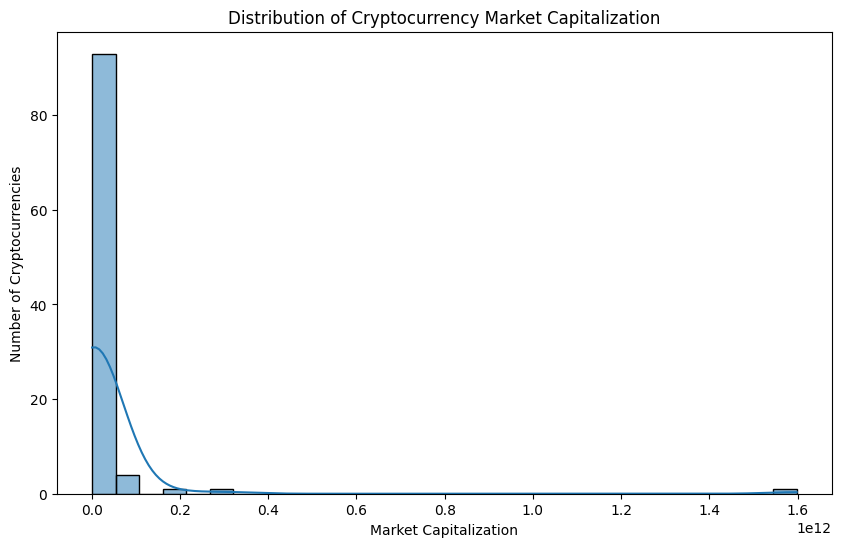

In [57]:

# Market Capitalization Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    crypto_clean["market_cap"],
    bins=30,
    kde=True
)

plt.title("Distribution of Cryptocurrency Market Capitalization")
plt.xlabel("Market Capitalization")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

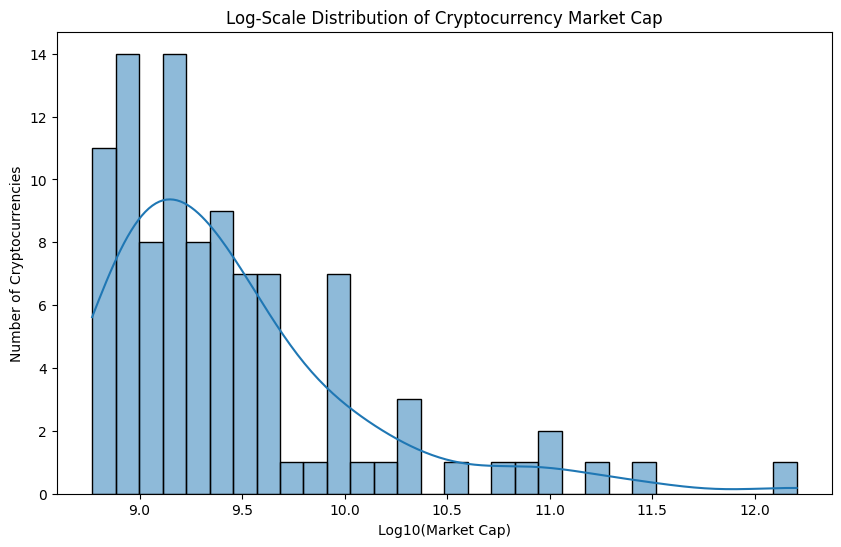

In [58]:

# Log-Scale Market Cap Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    np.log10(crypto_clean["market_cap"]),
    bins=30,
    kde=True
)

plt.title("Log-Scale Distribution of Cryptocurrency Market Cap")
plt.xlabel("Log10(Market Cap)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Price Distribution

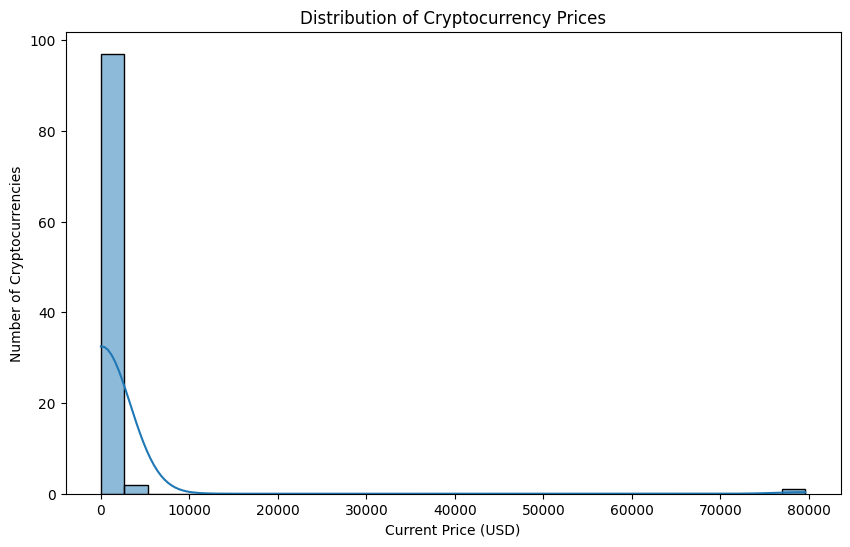

In [59]:

# Cryptocurrency Price Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    crypto_clean["current_price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Cryptocurrency Prices")
plt.xlabel("Current Price (USD)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

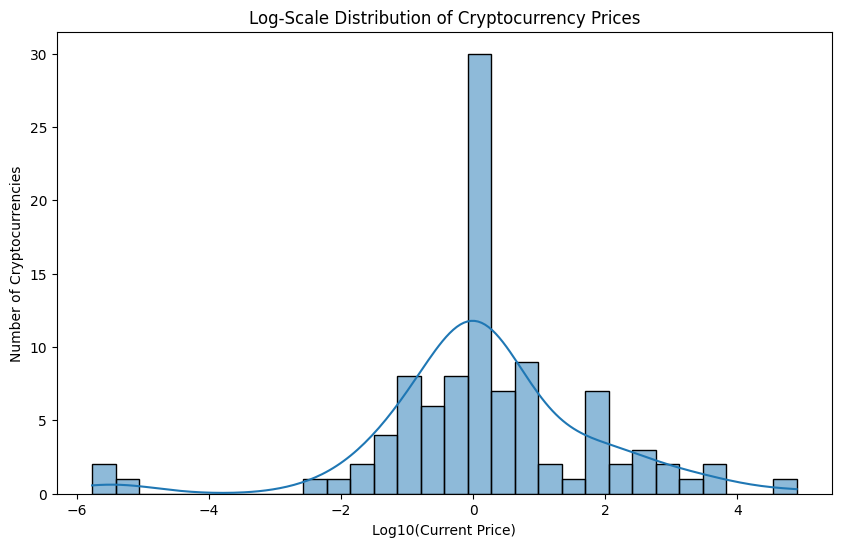

In [60]:

# Log-Scale Price Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    np.log10(crypto_clean["current_price"]),
    bins=30,
    kde=True
)

plt.title("Log-Scale Distribution of Cryptocurrency Prices")
plt.xlabel("Log10(Current Price)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Top Cryptocurrencies by Market Cap

In [61]:

# Top 10 Cryptocurrencies by Market Cap


top_market_cap = (
    crypto_clean
    .sort_values("market_cap", ascending=False)
    [["name", "symbol", "market_cap"]]
    .head(10)
)

top_market_cap

,name,symbol,market_cap
0,Bitcoin,btc,1598066676543
1,Ethereum,eth,306289554849
2,Tether,usdt,183424711629
3,BNB,bnb,99898084263
4,XRP,xrp,90117640590
5,USDC,usdc,74316339805
6,Solana,sol,61354019938
7,TRON,trx,32172210716
8,Figure Heloc,figr_heloc,23072571554
9,Zcash,zec,21390127439


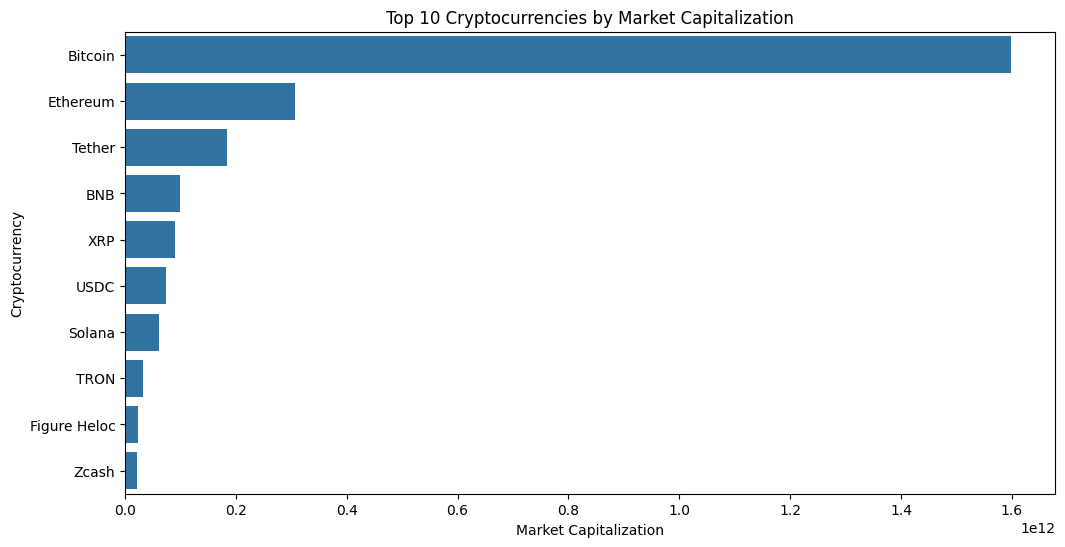

In [62]:

# Top 10 Market Cap Visualization


plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_market_cap,
    x="market_cap",
    y="name"
)

plt.title("Top 10 Cryptocurrencies by Market Capitalization")
plt.xlabel("Market Capitalization")
plt.ylabel("Cryptocurrency")

plt.show()

Trading Volume Analysis

In [63]:

# Top 10 Cryptocurrencies by Trading Volume


top_volume = (
    crypto_clean
    .sort_values("total_volume", ascending=False)
    [["name", "symbol", "total_volume"]]
    .head(10)
)

top_volume

,name,symbol,total_volume
2,Tether,usdt,5.347736e+10
0,Bitcoin,btc,3.458979e+10
5,USDC,usdc,1.505950e+10
1,Ethereum,eth,1.235283e+10
16,Chainlink,link,7.051795e+09
6,Solana,sol,2.882110e+09
4,XRP,xrp,2.691625e+09
9,Zcash,zec,1.287680e+09
33,Global Dollar,usdg,1.257867e+09
10,Hyperliquid,hype,1.090047e+09


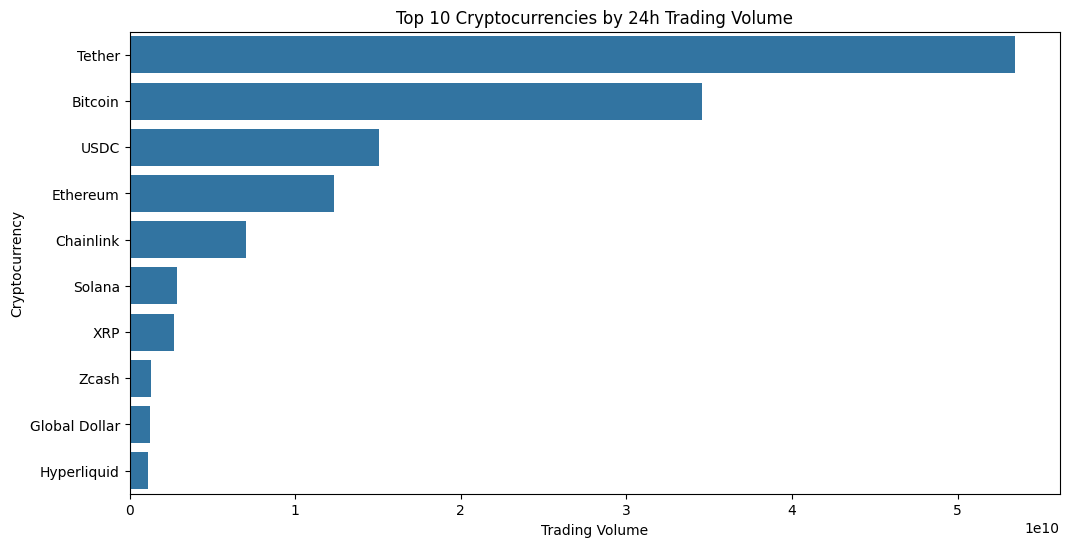

In [64]:

# Trading Volume Visualization


plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_volume,
    x="total_volume",
    y="name"
)

plt.title("Top 10 Cryptocurrencies by 24h Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Cryptocurrency")

plt.show()

Market Cap vs Trading Volume

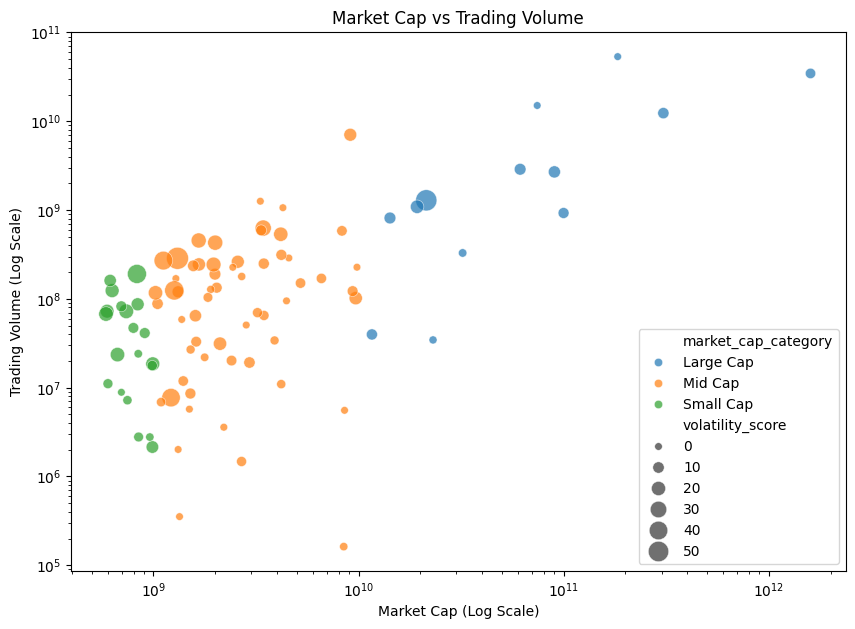

In [65]:

# Market Cap vs Trading Volume


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=crypto_clean,
    x="market_cap",
    y="total_volume",
    hue="market_cap_category",
    size="volatility_score",
    sizes=(30, 250),
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Market Cap vs Trading Volume")
plt.xlabel("Market Cap (Log Scale)")
plt.ylabel("Trading Volume (Log Scale)")

plt.show()

24h Price Change Analysis

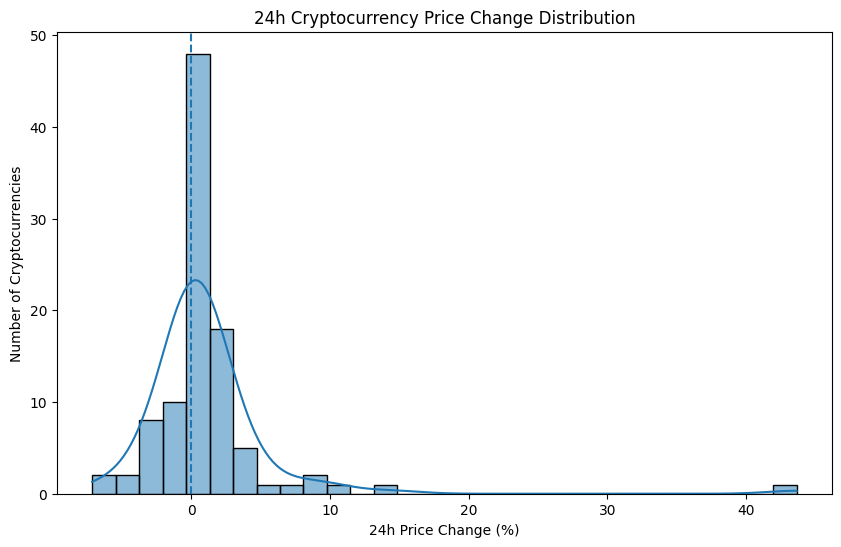

In [66]:

# 24h Price Change Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    crypto_clean["price_change_percentage_24h"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("24h Cryptocurrency Price Change Distribution")
plt.xlabel("24h Price Change (%)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Price Change Categories

In [67]:

# Price Change Category Counts

price_change_counts = (
    crypto_clean["price_change_category"]
    .value_counts()
)

price_change_counts

price_change_category
Gain           58
Loss           31
Strong Gain     7
Strong Loss     3
No Change       1
Name: count, dtype: int64

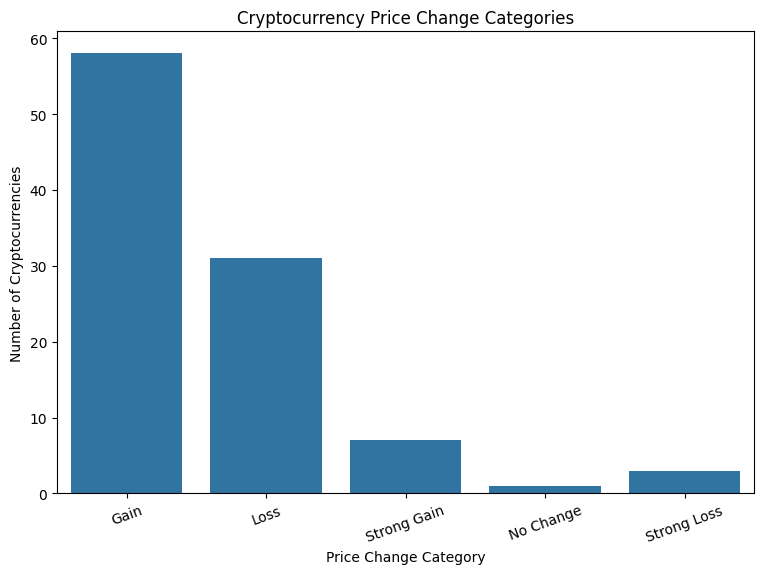

In [68]:

# Price Change Category Visualization


plt.figure(figsize=(9, 6))

sns.countplot(
    data=crypto_clean,
    x="price_change_category"
)

plt.title("Cryptocurrency Price Change Categories")
plt.xlabel("Price Change Category")
plt.ylabel("Number of Cryptocurrencies")

plt.xticks(rotation=20)

plt.show()

Volatility Analysis

In [69]:

# Volatility Category Counts


volatility_counts = (
    crypto_clean["volatility_category"]
    .value_counts()
)

volatility_counts

volatility_category
Medium    46
Low       39
High      15
Name: count, dtype: int64

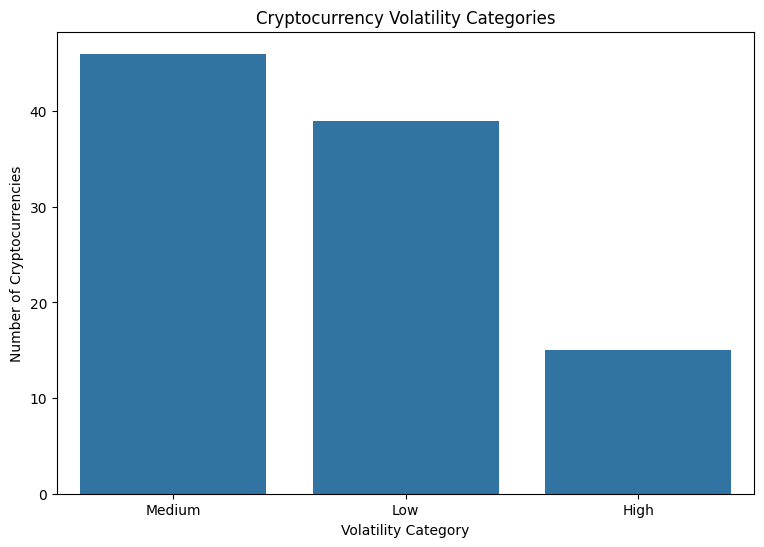

In [70]:

# Volatility Category Visualization


plt.figure(figsize=(9, 6))

sns.countplot(
    data=crypto_clean,
    x="volatility_category"
)

plt.title("Cryptocurrency Volatility Categories")
plt.xlabel("Volatility Category")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Market Cap Category Analysis

In [71]:

# Market Cap Category Distribution


market_cap_counts = (
    crypto_clean["market_cap_category"]
    .value_counts()
)

market_cap_counts

market_cap_category
Mid Cap      62
Small Cap    25
Large Cap    13
Name: count, dtype: int64

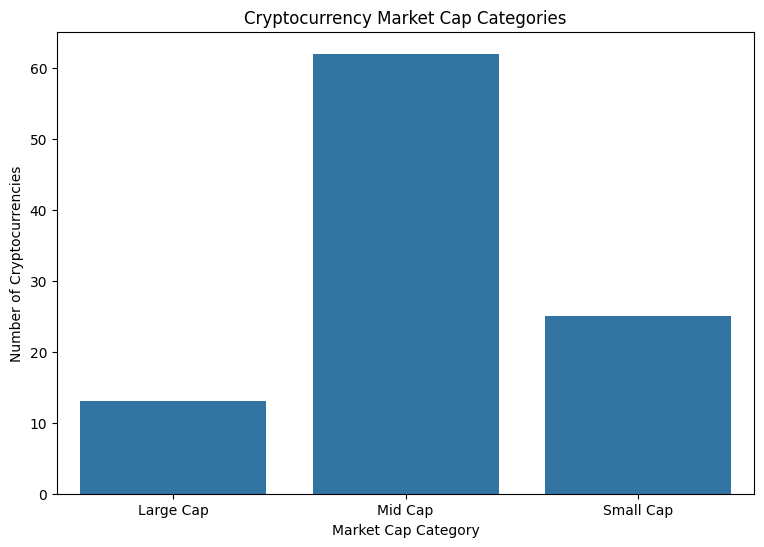

In [72]:

# Market Cap Category Visualization


plt.figure(figsize=(9, 6))

sns.countplot(
    data=crypto_clean,
    x="market_cap_category"
)

plt.title("Cryptocurrency Market Cap Categories")
plt.xlabel("Market Cap Category")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Volatility vs Market Cap

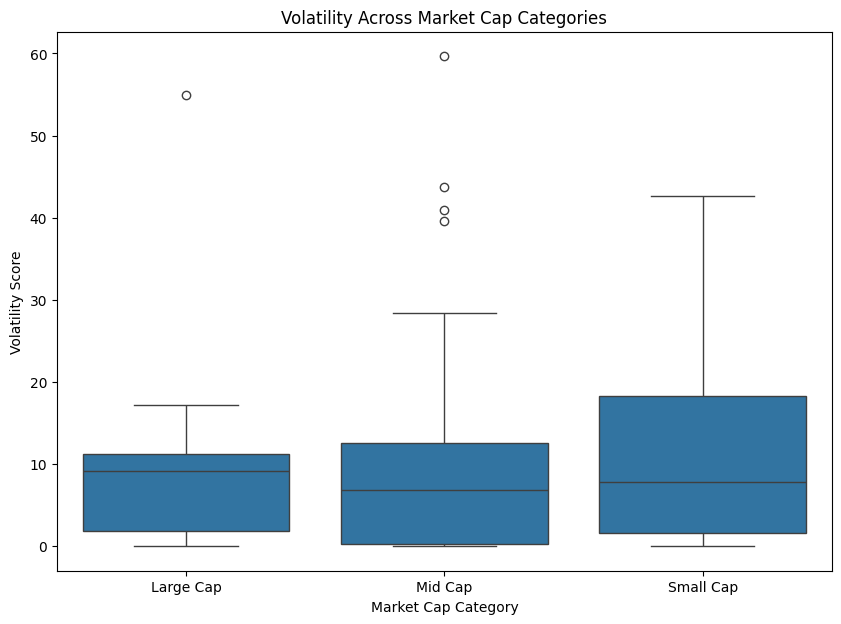

In [73]:

# Volatility vs Market Cap

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=crypto_clean,
    x="market_cap_category",
    y="volatility_score"
)

plt.title("Volatility Across Market Cap Categories")
plt.xlabel("Market Cap Category")
plt.ylabel("Volatility Score")

plt.show()

Correlation Analysis

In [74]:

# Select Important Numeric Features


correlation_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h",
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_7d_in_currency",
    "price_change_percentage_30d_in_currency",
    "volatility_score",
    "supply_ratio"
]

correlation_matrix = (
    crypto_clean[correlation_columns]
    .corr()
)

correlation_matrix

,current_price,market_cap,total_volume,price_change_percentage_24h,price_change_percentage_1h_in_currency,price_change_percentage_7d_in_currency,price_change_percentage_30d_in_currency,volatility_score,supply_ratio
current_price,1.000000,0.974257,0.509588,0.008922,0.014627,-0.046206,-0.014145,-0.028694,0.078092
market_cap,0.974257,1.000000,0.626244,0.008117,0.010817,-0.061365,-0.017859,-0.038232,0.091845
total_volume,0.509588,0.626244,1.000000,-0.013674,-0.027695,-0.090205,-0.066223,-0.085345,0.104980
price_change_percentage_24h,0.008922,0.008117,-0.013674,1.000000,0.331114,0.546217,0.421718,0.542702,-0.070480
price_change_percentage_1h_in_currency,0.014627,0.010817,-0.027695,0.331114,1.000000,0.411855,0.350700,0.421009,-0.268569
price_change_percentage_7d_in_currency,-0.046206,-0.061365,-0.090205,0.546217,0.411855,1.000000,0.734831,0.866403,-0.162963
price_change_percentage_30d_in_currency,-0.014145,-0.017859,-0.066223,0.421718,0.350700,0.734831,1.000000,0.958745,-0.337762
volatility_score,-0.028694,-0.038232,-0.085345,0.542702,0.421009,0.866403,0.958745,1.000000,-0.321118
supply_ratio,0.078092,0.091845,0.104980,-0.070480,-0.268569,-0.162963,-0.337762,-0.321118,1.000000


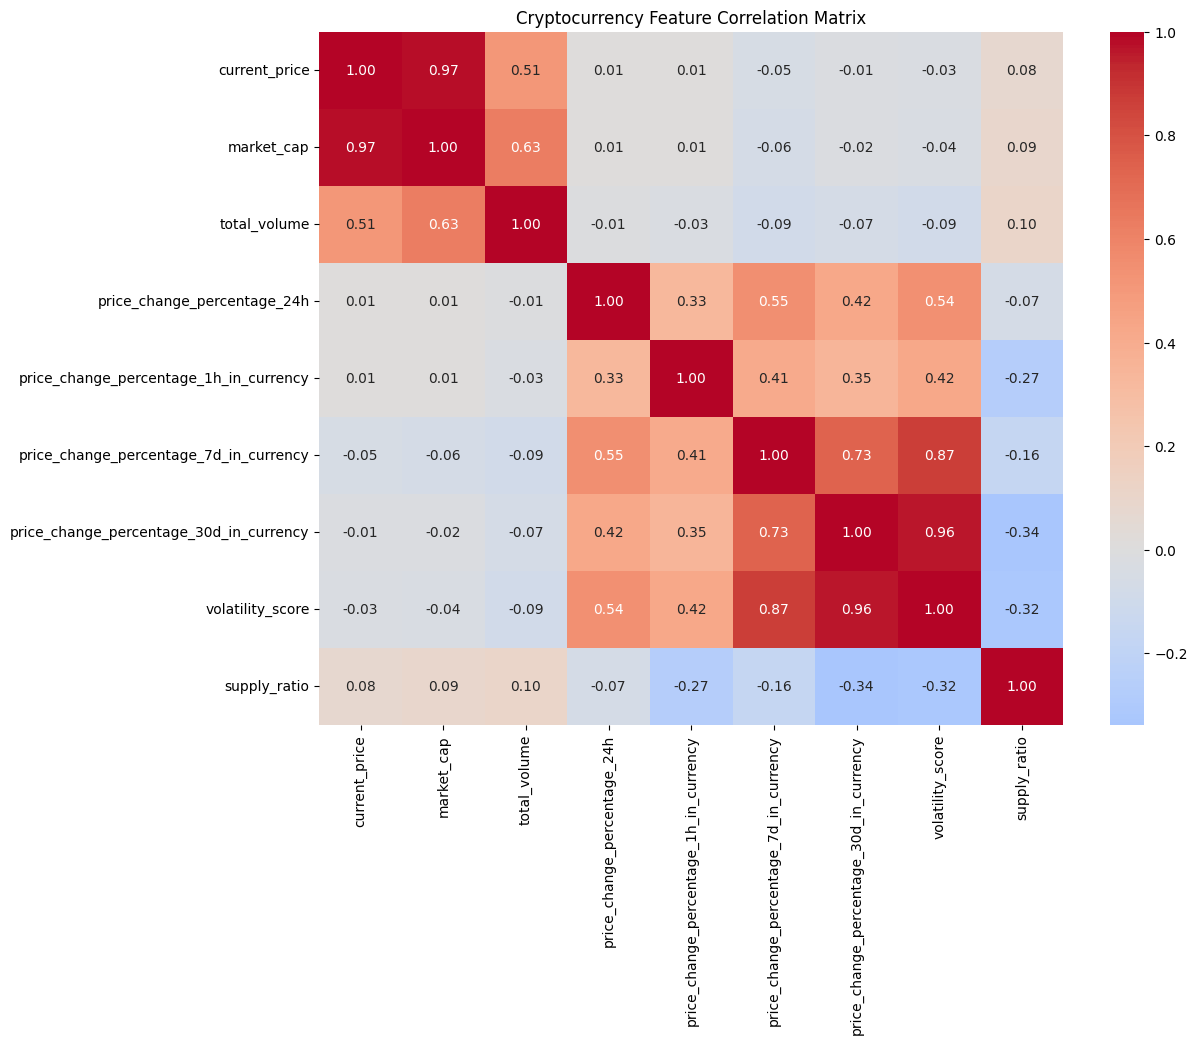

In [75]:

# Correlation Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Cryptocurrency Feature Correlation Matrix")

plt.show()

Most Volatile Cryptocurrencies

In [76]:

# Top 10 Most Volatile Cryptocurrencies


top_volatile = (
    crypto_clean
    .sort_values("volatility_score", ascending=False)
    [[
        "name",
        "symbol",
        "volatility_score",
        "volatility_category",
        "price_change_percentage_24h"
    ]]
    .head(10)
)

top_volatile

,name,symbol,volatility_score,volatility_category,price_change_percentage_24h
66,Venice Token,vvv,59.660825,High,43.64330
9,Zcash,zec,54.932318,High,8.92927
68,Lighter,lit,43.697495,High,4.48998
85,Dash,dash,42.663628,High,2.05451
71,Arbitrum,arb,40.908515,High,-2.73406
70,Bitway,btw,39.569892,High,0.47957
31,NEAR Protocol,near,28.451645,High,14.40658
47,Polkadot,dot,23.887345,High,7.74938
54,Ethena,ena,23.580670,High,3.22268
49,Pump.fun,pump,22.529422,High,9.51769


Highest 24h Gainers and Losers

In [77]:

# Top 10 24h Gainers

top_gainers = (
    crypto_clean
    .sort_values(
        "price_change_percentage_24h",
        ascending=False
    )
    [["name", "symbol", "price_change_percentage_24h"]]
    .head(10)
)

top_gainers

,name,symbol,price_change_percentage_24h
66,Venice Token,vvv,43.64330
31,NEAR Protocol,near,14.40658
74,Cosmos Hub,atom,10.04433
49,Pump.fun,pump,9.51769
9,Zcash,zec,8.92927
47,Polkadot,dot,7.74938
41,Bittensor,tao,5.95217
98,Ether.fi,ethfi,4.49392
68,Lighter,lit,4.48998
84,Jupiter,jup,4.32591


In [78]:

# Top 10 24h Losers

top_losers = (
    crypto_clean
    .sort_values(
        "price_change_percentage_24h",
        ascending=True
    )
    [["name", "symbol", "price_change_percentage_24h"]]
    .head(10)
)
top_losers


,name,symbol,price_change_percentage_24h
99,Aerodrome Finance,aero,-7.16364
56,Internet Computer,icp,-6.22744
53,Worldcoin,wld,-5.10715
59,Sky,sky,-3.95721
55,Morpho,morpho,-3.44081
27,Uniswap,uni,-3.25811
83,JUST,jst,-2.99556
16,Chainlink,link,-2.76107
71,Arbitrum,arb,-2.73406
12,Rain,rain,-2.25920
